<a href="https://colab.research.google.com/github/rayyan4676t7/credit-card-fraud-detection/blob/main/credit_card_fraud_dataset.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Credit Card Fraud Detection using Machine Learning

## Introduction
Fraud detection is a critical problem in financial systems where the goal is to identify fraudulent transactions.
Due to the increasing number of digital transactions, detecting fraud automatically using machine learning has become essential.

This project aims to detect fraudulent transactions using anomaly detection techniques.

In [1]:
import numpy as np # linear algebra
import pandas as pd # data processing
import matplotlib.pyplot as plt
import seaborn as sns
! pip install plotly
import plotly.express as px



import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

## Import & Load Data

In [2]:
df = pd.read_csv("creditcard.csv")
df

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0.0
1,0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0.0
2,1,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0.0
3,1,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0.0
4,2,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
23853,32953,1.296815,-0.518508,0.348800,0.129750,-0.845934,-0.283287,-0.463165,-0.007344,-0.530097,...,-0.498652,-0.791893,0.058456,0.067753,0.367979,0.400899,0.005089,0.008846,14.00,0.0
23854,32954,1.295646,-0.699613,-1.129649,-2.505043,1.428275,3.010605,-0.892932,0.798386,1.309837,...,0.071540,0.120545,-0.144172,1.066577,0.615628,0.123208,0.013875,0.018547,37.07,0.0
23855,32954,-1.691394,-1.452403,1.671861,-1.769590,1.636843,-0.943701,0.193116,-0.712756,-0.987725,...,0.047745,0.539167,-0.698010,-0.470563,0.621828,-0.254508,-0.724865,-0.360165,53.80,0.0
23856,32954,1.112786,0.062772,1.481419,2.922471,-0.905121,0.366357,-0.670663,0.256586,0.599399,...,0.010125,0.346740,-0.117334,0.416103,0.586102,0.216021,0.042710,0.024984,0.00,0.0


## Dataset Description

The dataset contains credit card transactions.

- Class = 0 → Normal transaction  
- Class = 1 → Fraud transaction  

The dataset is highly imbalanced, meaning fraud cases are very rare compared to normal transactions.

## Basic Info

In [3]:
df.head(15)

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0.0
1,0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0.0
2,1,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0.0
3,1,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0.0
4,2,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0.0
5,2,-0.425966,0.960523,1.141109,-0.168252,0.420987,-0.029728,0.476201,0.260314,-0.568671,...,-0.208254,-0.559825,-0.026398,-0.371427,-0.232794,0.105915,0.253844,0.081080,3.67,0.0
6,4,1.229658,0.141004,0.045371,1.202613,0.191881,0.272708,-0.005159,0.081213,0.464960,...,-0.167716,-0.270710,-0.154104,-0.780055,0.750137,-0.257237,0.034507,0.005168,4.99,0.0
7,7,-0.644269,1.417964,1.074380,-0.492199,0.948934,0.428118,1.120631,-3.807864,0.615375,...,1.943465,-1.015455,0.057504,-0.649709,-0.415267,-0.051634,-1.206921,-1.085339,40.80,0.0
8,7,-0.894286,0.286157,-0.113192,-0.271526,2.669599,3.721818,0.370145,0.851084,-0.392048,...,-0.073425,-0.268092,-0.204233,1.011592,0.373205,-0.384157,0.011747,0.142404,93.20,0.0
9,9,-0.338262,1.119593,1.044367,-0.222187,0.499361,-0.246761,0.651583,0.069539,-0.736727,...,-0.246914,-0.633753,-0.120794,-0.385050,-0.069733,0.094199,0.246219,0.083076,3.68,0.0


In [4]:
df.tail(15)

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
23843,32947,-1.037804,-1.309110,1.637188,-2.506316,-0.367156,-0.030879,0.221190,-0.092337,-2.653680,...,0.085652,0.288131,0.082866,-0.337659,0.524407,-0.168021,-0.186601,-0.160944,176.00,0.0
23844,32948,1.311258,0.075028,-1.292832,-0.483154,2.139257,3.181564,-0.505045,0.804860,-0.074071,...,-0.342676,-1.148504,0.095279,0.946121,0.369713,0.110626,-0.021837,0.023638,1.98,0.0
23845,32949,1.005733,-0.606410,1.634574,1.097761,-1.273045,0.913509,-1.112112,0.543204,1.478293,...,-0.118558,0.079930,0.020805,0.275724,0.230382,0.387984,0.050957,0.015117,22.65,0.0
23846,32950,1.273745,0.278094,-0.075297,0.446751,0.215297,-0.125249,-0.017577,-0.004897,0.103271,...,-0.316963,-0.878888,0.057085,-0.810224,0.251885,0.176653,-0.008267,0.018517,0.99,0.0
23847,32950,1.270657,-0.015979,-0.570280,-0.599660,0.345627,-0.421329,0.377731,-0.218896,-0.418741,...,-0.380266,-1.229651,-0.046107,-0.763469,0.268750,1.131307,-0.144367,-0.017332,56.85,0.0
23848,32950,1.339313,-0.540442,0.622292,-0.633545,-1.167985,-0.939272,-0.567723,-0.223493,-0.801198,...,0.134547,0.267939,-0.019603,0.427333,0.377502,-0.289209,0.014915,0.028799,42.00,0.0
23849,32951,-1.332027,0.636514,0.476737,1.343294,0.460551,0.247225,-0.054335,0.511931,-0.117580,...,-0.090339,-0.095190,-0.461555,-0.735143,0.214399,-0.159408,0.057776,-0.104813,29.32,0.0
23850,32952,-0.220983,-0.391480,-0.685256,-3.460632,1.220017,3.103783,-1.159196,1.246351,-2.518314,...,-0.127651,-0.325462,0.010873,0.961228,-0.093527,-0.407212,-0.055330,-0.035154,10.00,0.0
23851,32952,1.306426,0.307129,0.183381,0.416353,0.046614,-0.477277,0.149294,-0.233948,-0.111937,...,-0.291961,-0.787030,0.009612,-0.421341,0.374374,0.141072,-0.022295,0.014803,8.99,0.0
23852,32952,-5.696128,-12.082869,-3.207362,1.680961,-4.968175,0.353113,4.073796,-0.957351,1.620758,...,2.290948,-1.361236,-3.275394,0.626658,-0.861891,-0.267888,-0.640288,0.649795,3610.00,0.0


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23858 entries, 0 to 23857
Data columns (total 31 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Time    23858 non-null  int64  
 1   V1      23858 non-null  float64
 2   V2      23858 non-null  float64
 3   V3      23858 non-null  float64
 4   V4      23858 non-null  float64
 5   V5      23858 non-null  float64
 6   V6      23858 non-null  float64
 7   V7      23858 non-null  float64
 8   V8      23858 non-null  float64
 9   V9      23858 non-null  float64
 10  V10     23858 non-null  float64
 11  V11     23858 non-null  float64
 12  V12     23858 non-null  float64
 13  V13     23858 non-null  float64
 14  V14     23858 non-null  float64
 15  V15     23858 non-null  float64
 16  V16     23858 non-null  float64
 17  V17     23858 non-null  float64
 18  V18     23858 non-null  float64
 19  V19     23858 non-null  float64
 20  V20     23858 non-null  float64
 21  V21     23858 non-null  float64
 22

In [6]:
df.describe()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,23858.000000,23858.000000,23858.000000,23858.000000,23858.000000,23858.000000,23858.000000,23858.000000,23858.000000,23858.000000,...,23858.000000,23857.000000,23857.000000,23857.000000,23857.000000,23857.000000,23857.000000,23857.000000,23857.000000,23857.000000
mean,18213.370609,-0.239141,0.198892,0.727022,0.248619,-0.188428,0.082789,-0.132080,0.022901,0.499391,...,-0.041192,-0.137287,-0.038435,0.013626,0.127921,0.027504,0.013233,0.004932,73.976583,0.003689
std,11377.032190,1.894219,1.533073,1.724887,1.440938,1.439894,1.328159,1.334691,1.378382,1.274199,...,0.837207,0.644720,0.526298,0.588573,0.435896,0.520213,0.401059,0.267790,212.761278,0.060623
min,0.000000,-30.552380,-40.978852,-31.103685,-5.172595,-42.147898,-23.496714,-26.548144,-41.484823,-7.175097,...,-20.262054,-8.593642,-26.751119,-2.836627,-7.495741,-1.338556,-8.567638,-9.617915,0.000000,0.000000
25%,6624.750000,-0.959528,-0.376134,0.287941,-0.658457,-0.767634,-0.663707,-0.595277,-0.167688,-0.330826,...,-0.253906,-0.561223,-0.173814,-0.325615,-0.134460,-0.337167,-0.066242,-0.009446,5.990000,0.000000
50%,20564.000000,-0.288644,0.192491,0.874426,0.216440,-0.218348,-0.179887,-0.066356,0.027183,0.422417,...,-0.104848,-0.110305,-0.048570,0.064300,0.164769,-0.046463,0.006465,0.020002,18.040000,0.000000
75%,29010.250000,1.164867,0.843146,1.505467,1.122367,0.325281,0.474103,0.450460,0.286111,1.261519,...,0.066305,0.273088,0.074189,0.400535,0.407827,0.314884,0.094960,0.077392,66.000000,0.000000
max,32954.000000,1.960497,16.713389,4.101716,11.927512,34.099309,22.529298,36.677268,20.007208,10.392889,...,22.614889,5.805795,13.876221,3.695503,5.525093,3.517346,11.135740,4.860769,7879.420000,1.000000


In [7]:
# Check missing values
df.isnull().sum()


,0
Time,0
V1,0
V2,0
V3,0
V4,0
V5,0
V6,0
V7,0
V8,0
V9,0


In [8]:
df = df.dropna()

## boxplot : Amount vs Fraud

<Axes: xlabel='Class', ylabel='Amount'>

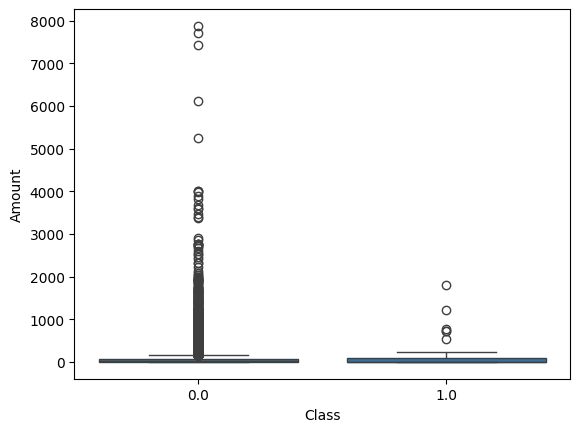

In [9]:
sns.boxplot(x='Class', y='Amount', data=df)


## Feature Distributions

<Figure size 1200x800 with 0 Axes>

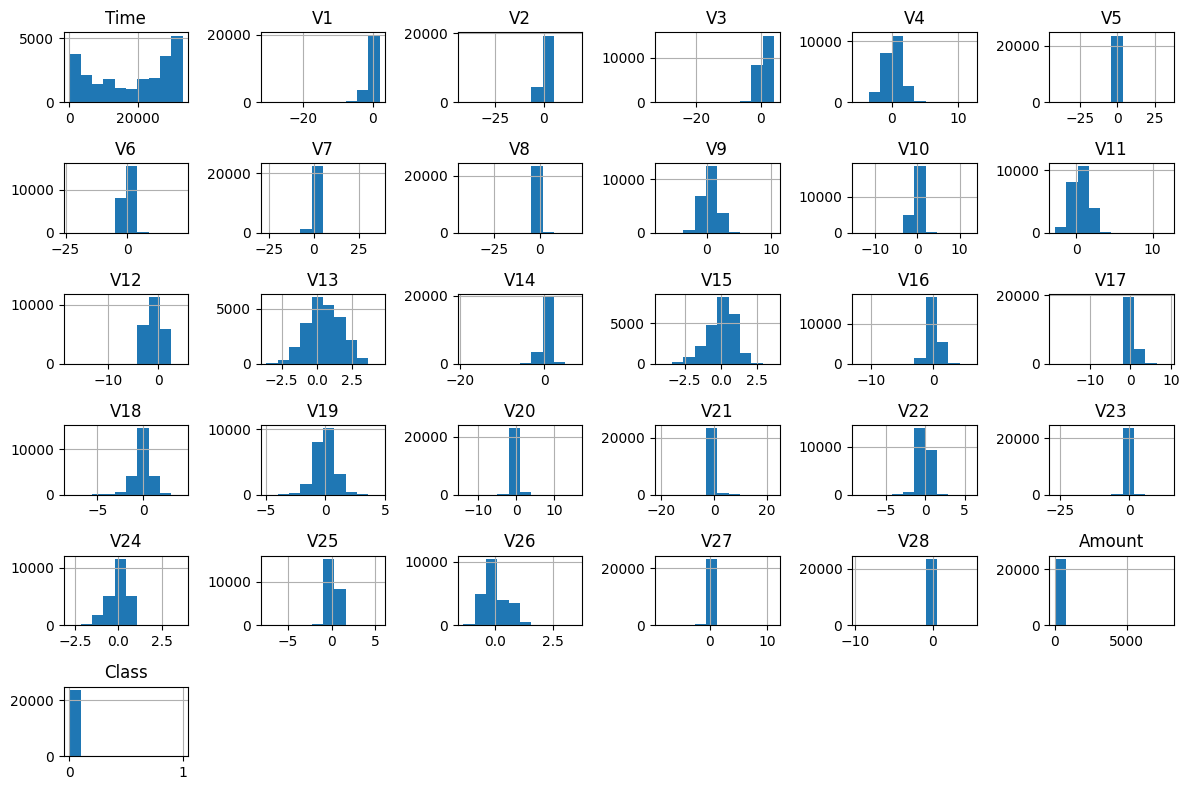

In [10]:
plt.figure(figsize=(12, 8))
df.hist(figsize=(12, 8))
plt.tight_layout()
plt.show()

## Heatmap

In [11]:
numeric_df = df.select_dtypes(include='number')

corr_matrix = numeric_df.corr()

fig = px.imshow(
    corr_matrix,
    text_auto=True,
    color_continuous_scale='RdBu_r',
    zmin=-1,
    zmax=1,
    aspect='auto',
    title='✨ Correlation Heatmap of Numeric Features (Credit Card Fraud)'
)

fig.update_layout(
    template='plotly_white',
    height=800
)

fig.show()

## MRP

In [12]:
import plotly.express as px

fig = px.box(
    df,
    x='Class',
    y='Amount',
    color='Class',
    color_discrete_map={0: 'teal', 1: 'pink'},
    points="all",
    title="Transaction Amount Distribution by Class"
)

fig.update_layout(
    xaxis_title="Class (0=Normal, 1=Fraud)",
    yaxis_title="Transaction Amount",
    template='plotly_white'
)

fig.show()

## barchart

In [13]:
top_classes = df['Class'].value_counts().reset_index()
top_classes.columns = ['Class', 'Count']

fig = px.bar(
    top_classes,
    x='Count',
    y='Class',
    orientation='h',
    color='Class',
    color_discrete_map={0: 'teal', 1: 'pink'},
    title='Number of Transactions by Class'
)

fig.update_layout(
    height=400,
    yaxis={'categoryorder': 'total ascending'},
    xaxis_title='Number of Transactions',
    yaxis_title='Class',
    template='plotly_white'
)

fig.show()

## scatter

In [14]:
df_sample = df.sample(n=5000, random_state=42)

fig = px.scatter(
    df_sample,
    x='Time',
    y='Amount',
    color='Class',
    color_discrete_map={0: 'teal', 1: 'pink'},
    hover_data=['V1', 'V2', 'V3', 'V4', 'V5'],
    title='Transaction Amount vs Time by Class (Sample)'
)

fig.update_layout(
    xaxis_title='Time (seconds)',
    yaxis_title='Transaction Amount',
    template='plotly_white',
    height=600
)

fig.show()

## Bubble Scatter

In [15]:
df_sample = df.sample(n=5000, random_state=42)

df_sample['V1_size'] = df_sample['V1'].abs() + 0.1


fig = px.scatter(
    df_sample,
    x='Time',
    y='Amount',
    size='V1_size',
    color='Class',
    hover_data=['V1', 'V2', 'V3', 'V4', 'V5'],
    title='Transaction Amount vs Time by Class',
    size_max=60,
    color_discrete_map={0: 'teal', 1: 'pink'}
)

fig.update_layout(
    xaxis_title='Time (seconds)',
    yaxis_title='Transaction Amount',
    template='plotly_white',
    height=600
)

fig.show()



## plotly line

In [16]:
import plotly.express as px

# Sample data
df_sample = df.sample(n=10000, random_state=42)

# Sort by time
df_sample_sorted = df_sample.sort_values('Time')

# Create smoothed column (BEST method)
df_sample_sorted['Amount_Smooth'] = df_sample_sorted.groupby('Class')['Amount'] \
    .transform(lambda x: x.rolling(window=50, min_periods=1).mean())

# Plot
fig = px.line(
    df_sample_sorted,
    x='Time',
    y='Amount_Smooth',
    color='Class',
    line_dash='Class',
    markers=True,
    title='Smoothed Transaction Amount by Time and Class'
)

fig.update_layout(
    xaxis_title='Time (seconds)',
    yaxis_title='Transaction Amount (Smoothed)',
    template='plotly_white',
    height=600
)

fig.show()

## Pie Chart

In [17]:
top_classes = df['Class'].value_counts().reset_index()
top_classes.columns = ['Class', 'Count']

fig = px.pie(
    top_classes,
    names='Class',
    values='Count',
    title='Distribution of Transactions by Class',
    color='Class',
    color_discrete_map={0: 'teal', 1: 'pink'}
)


pull = [0.1 if i == 0 else 0 for i in range(len(top_classes))]
fig.update_traces(textinfo='percent+label', pull=pull)

fig.update_layout(legend_title_text='Class')

fig.show()

In [18]:
df = df.dropna()

In [19]:
X = df.drop("Class", axis=1)
y = df["Class"]

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [20]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

## Model Used

Logistic Regression was used as the classification model.

It is a supervised learning algorithm that predicts whether a transaction is fraudulent or not.

In [21]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

model = LogisticRegression(max_iter=2000)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("Normal Logistic Regression:\n")
print(classification_report(y_test, y_pred))

Normal Logistic Regression:

              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00      4758
         1.0       0.80      0.57      0.67        14

    accuracy                           1.00      4772
   macro avg       0.90      0.79      0.83      4772
weighted avg       1.00      1.00      1.00      4772



In [22]:
model_balanced = LogisticRegression(max_iter=2000, class_weight="balanced")
model_balanced.fit(X_train, y_train)

y_pred_bal = model_balanced.predict(X_test)

print("Balanced Logistic Regression:\n")
print(classification_report(y_test, y_pred_bal))

Balanced Logistic Regression:

              precision    recall  f1-score   support

         0.0       1.00      0.99      0.99      4758
         1.0       0.20      0.93      0.33        14

    accuracy                           0.99      4772
   macro avg       0.60      0.96      0.66      4772
weighted avg       1.00      0.99      0.99      4772



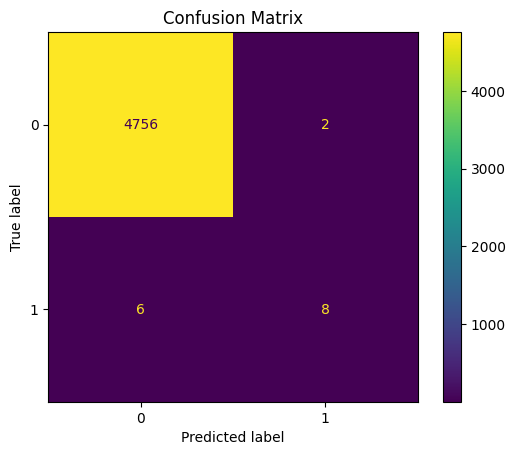

In [23]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()

plt.title("Confusion Matrix")
plt.show()

## Results Interpretation

The dataset is highly imbalanced, so accuracy is not a reliable metric.

The normal model achieved good precision but missed some fraud cases.

After applying class balancing, recall improved, meaning more fraud cases were detected.

However, precision decreased, leading to more false positives.

This demonstrates the trade-off between precision and recall.

## Conclusion

This project demonstrates the challenges of fraud detection using machine learning.

Due to class imbalance, accuracy is not a reliable metric.

Different models and techniques result in trade-offs between precision and recall.

Choosing the right model depends on the application requirements, especially in critical domains like fraud detection.